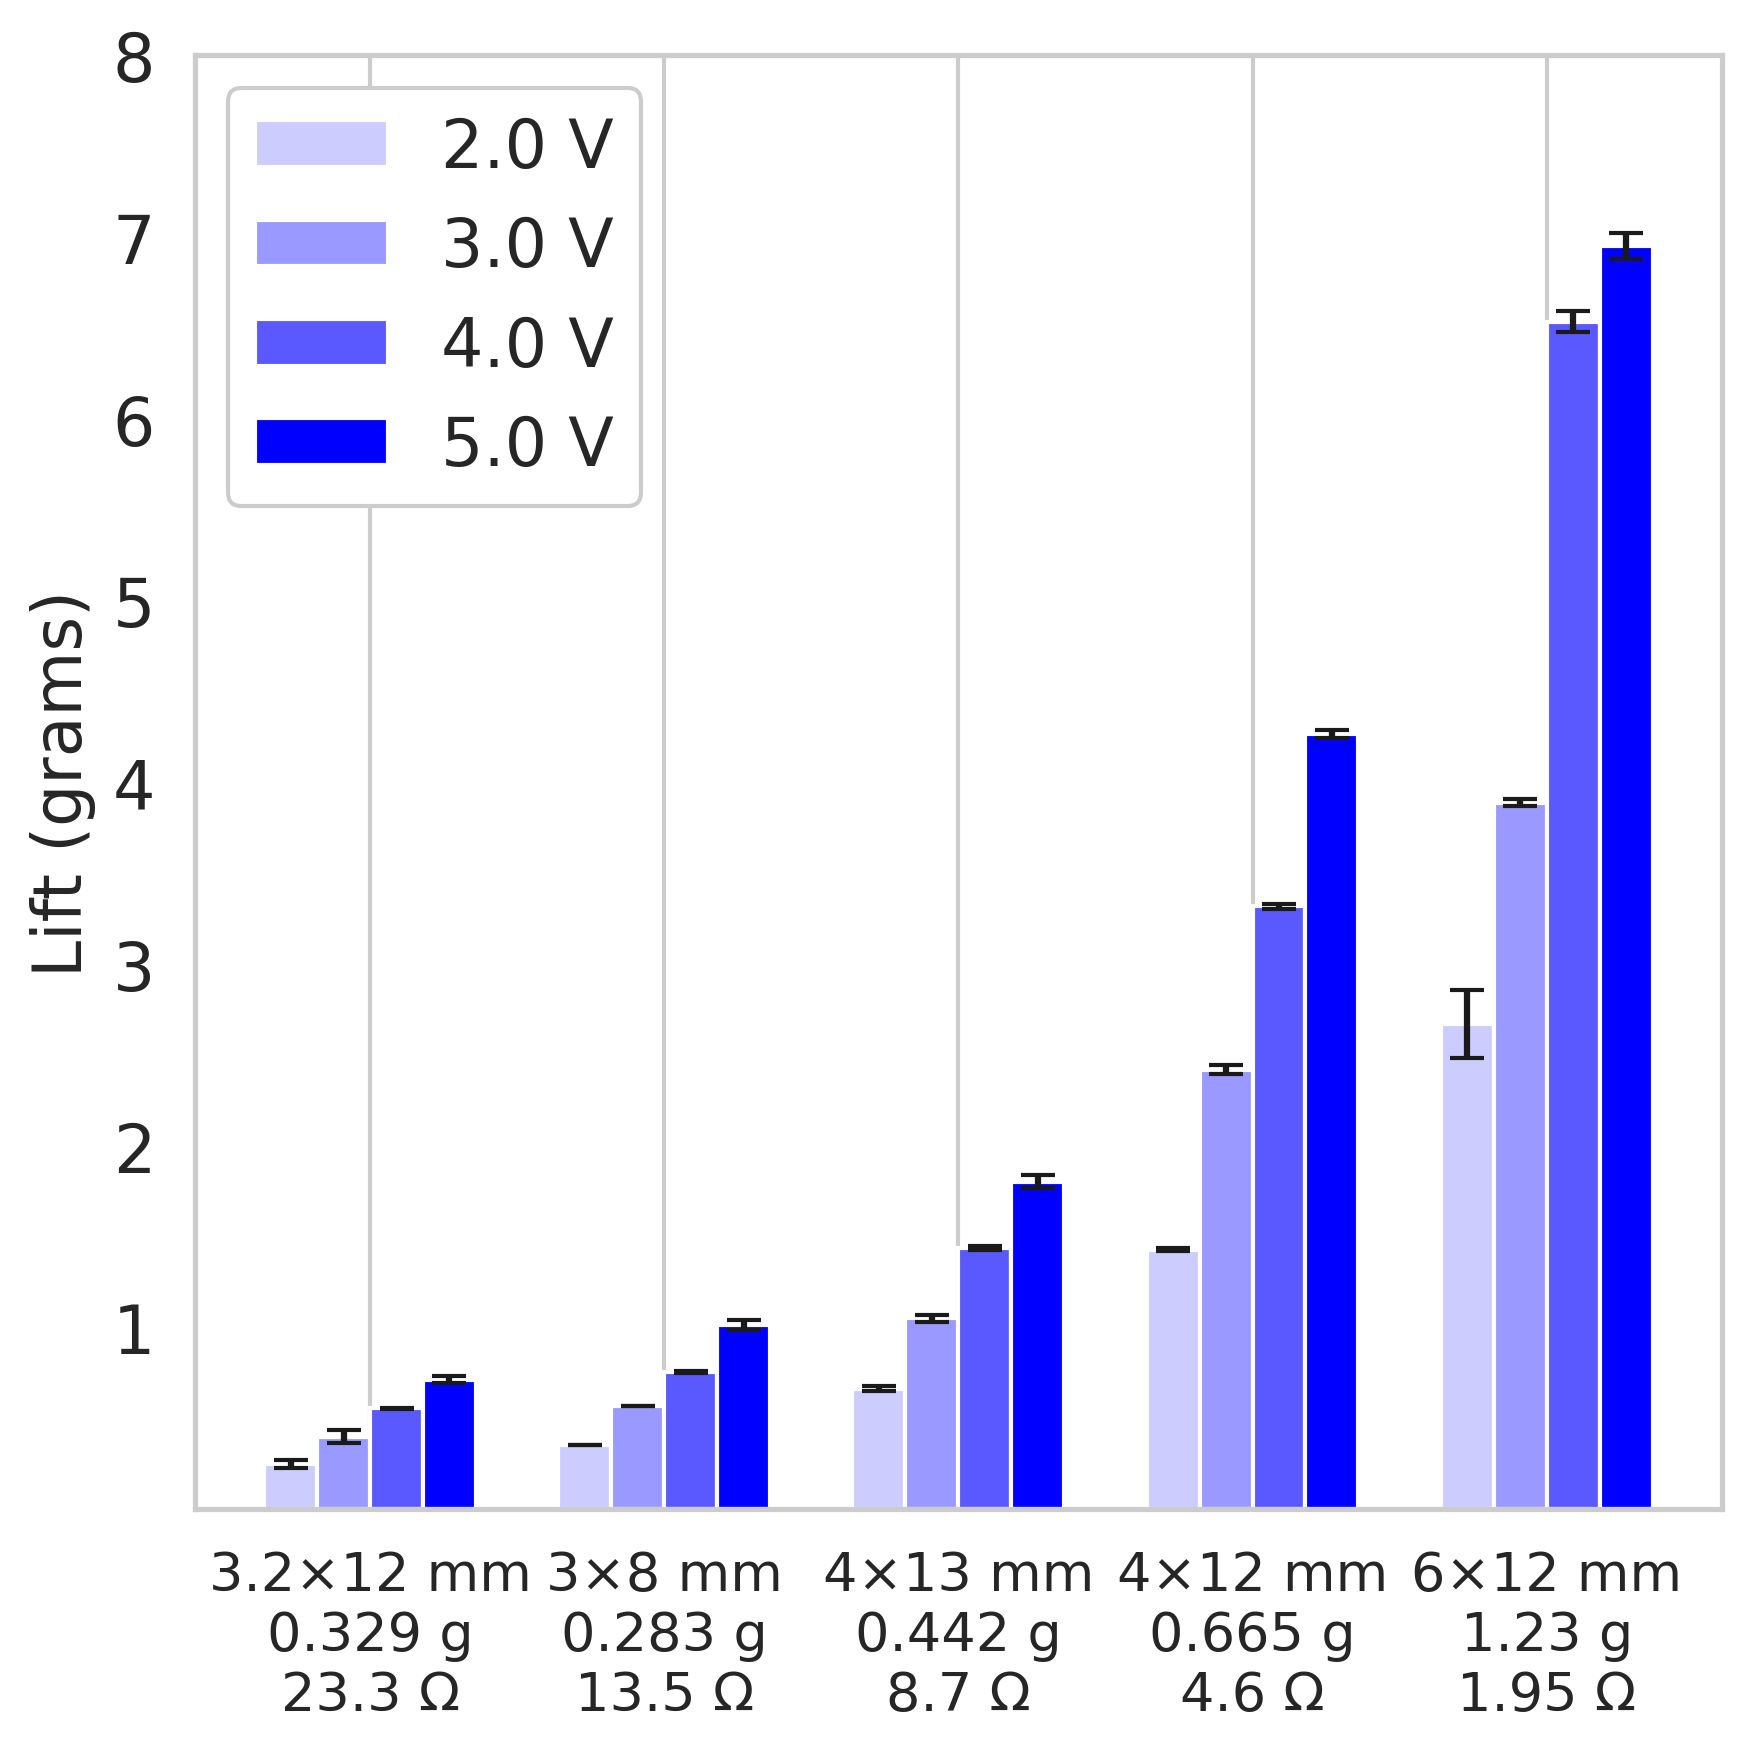

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load and clean data
sheet_url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRbUyCT7zYiZOZQs56IO_Uy5lv-ymGmqzKlgwTJ1VMfxoPH9yQzRnAPnQa3Iwf6dtvrWCJ0Dnt2prUU/pub?gid=696352816&single=true&output=csv'
df = pd.read_csv(sheet_url)

df = df.dropna(subset=['Motor Variant', 'Motor Size (mm)', 'Motor Weight (g)',
                       'Motor Resistance (Ω)', 'Lift (grams)', 'Motor Voltage (V)'])

# Create simplified motor ID
df['Motor_Info'] = (#df['Motor Variant'] + "\n" +
                    df['Motor Size (mm)'].astype(str) + " mm\n" +
                    df['Motor Weight (g)'].astype(str) + " g\n" + #"\n" +
                    df['Motor Resistance (Ω)'].astype(str) + " Ω")

# Group by Motor_Info and Voltage, get mean and std
grouped = df.groupby(['Motor_Info', 'Motor Voltage (V)'])['Lift (grams)'].agg(['mean', 'std']).reset_index()

# Reorder Motor_Info based on overall mean lift (ascending) to move smallest section to the left
motor_order = grouped.groupby('Motor_Info')['mean'].mean().sort_values().index.tolist()
grouped['Motor_Info'] = pd.Categorical(grouped['Motor_Info'], categories=motor_order, ordered=True)
grouped = grouped.sort_values('Motor_Info')

# Plot
plt.figure(figsize=(6, 6), dpi=300)
plt.rcParams.update({'font.size': 14}) # Set the font size for all text in the plot
sns.set(style='whitegrid')

# Get unique motor types and voltages
motor_types = grouped['Motor_Info'].cat.categories
voltages = grouped['Motor Voltage (V)'].unique()

# Define a manual color scheme
color_scheme = {
    2.0: "#0000FF33", # 20% opacity
    3.0: "#0000FF66", # 40% opacity
    4.0: "#0000FFA6", # 65% opacity
    5.0: "#0000FFFF"  # 100% opacity
}

# Bar width and offsets
bar_width = 0.18
x = np.arange(len(motor_types))

# Plot bars
for i, voltage in enumerate(voltages):
    subset = grouped[grouped['Motor Voltage (V)'] == voltage]
    means = subset['mean']
    stds = subset['std']
    color = color_scheme.get(voltage, None)
    plt.bar(x + i*bar_width, means, yerr=stds, width=bar_width, label=f'{voltage} V', color=color, capsize=4)

# Set text size
plt.rcParams.update({
    'font.size': 12,         # Base font size for everything
    'axes.labelsize': 16,    # Axis label font size
    'xtick.labelsize': 16,   # X tick labels
    'ytick.labelsize': 16,   # Y tick labels
    'legend.fontsize': 16,   # Legend text
    'axes.titlesize': 16     # Title font size (if used)
})

# Formatting
plt.xticks(x + bar_width * (len(voltages) - 1) / 2, motor_types, ha='center', fontsize=13) # rotation=45,
plt.ylabel('Lift (grams)', fontsize=16)
plt.yticks([1, 2, 3, 4, 5, 6, 7, 8], fontsize=16)
#plt.xlabel('Motor Type')
# Enable axes grids
plt.gca().grid(True)
plt.gca().yaxis.grid(False) # disable x-axis grid lines
#plt.title('Lift Comparison by Motor Type and Voltage')
plt.legend(facecolor='white', framealpha=1) # title='Motor Voltage'
plt.tight_layout()
plt.show()